# Nexus Glass Key — Wave-Guided Recovery Lab

This notebook is the **wave-first** version of the Glass Key lab.

The working thesis is:

$$
\text{noun} \to \text{gap} \to \text{kinetic motion} \to \text{waveform} \to \text{rendered value}
$$

For SHA-256, that means:

- the **value channel** is the final rendered projection
- the **shape / motion channel** is the round-by-round kinetic field
- the **schedule** is not just a list of words; it is a branching waveguide
- the job is not blind bit guessing, but **pressure steering** across the fold trajectory

This notebook is intentionally **big** and organized around that idea.

## Main sections

1. **Exact SHA machinery**  
   Forward trace, per-round observables, exact block replay, exact known-schedule reverse step.

2. **Kinetic / transport probes**  
   Changed lanes, changed bits, support onset, block boundary behavior.

3. **Waveform dashboard**  
   State, `T1`, `T2`, and schedule divergence as waveforms.

4. **FFT / spectral steering**  
   Frequency content, return spacing, schedule resonance.

5. **Recursive route pressure**  
   Path multiplicity, the `1 / 3 / 5` law, later return ladders.

6. **Wave-guided pressure field**  
   Composite ranking of schedule indices using exact route structure plus measured spectral response.

7. **Corrected blockwise reverse checks**  
   Reverse per block using the known schedule and the correct chaining input for that block.

8. **Appendix: separate 112-byte branch**  
   Kept separate from the SHA recovery branch.

This notebook treats the wave layer as the **primary navigation surface** and the exact algebra as the calibration rail.


In [1]:
# Optional install cell
# Uncomment if your environment is missing these.
# %pip install numpy matplotlib pandas

print("Environment cell ready.")


Environment cell ready.


In [2]:
from __future__ import annotations

import struct
import hashlib
import math
from dataclasses import dataclass
from typing import List, Tuple, Dict, Optional

import numpy as np
import matplotlib.pyplot as plt

try:
    import pandas as pd
except Exception:
    pd = None

M32 = 0xFFFFFFFF

STD_H = [
    0x6A09E667, 0xBB67AE85, 0x3C6EF372, 0xA54FF53A,
    0x510E527F, 0x9B05688C, 0x1F83D9AB, 0x5BE0CD19,
]

STD_K = [
    0x428A2F98, 0x71374491, 0xB5C0FBCF, 0xE9B5DBA5, 0x3956C25B, 0x59F111F1, 0x923F82A4, 0xAB1C5ED5,
    0xD807AA98, 0x12835B01, 0x243185BE, 0x550C7DC3, 0x72BE5D74, 0x80DEB1FE, 0x9BDC06A7, 0xC19BF174,
    0xE49B69C1, 0xEFBE4786, 0x0FC19DC6, 0x240CA1CC, 0x2DE92C6F, 0x4A7484AA, 0x5CB0A9DC, 0x76F988DA,
    0x983E5152, 0xA831C66D, 0xB00327C8, 0xBF597FC7, 0xC6E00BF3, 0xD5A79147, 0x06CA6351, 0x14292967,
    0x27B70A85, 0x2E1B2138, 0x4D2C6DFC, 0x53380D13, 0x650A7354, 0x766A0ABB, 0x81C2C92E, 0x92722C85,
    0xA2BFE8A1, 0xA81A664B, 0xC24B8B70, 0xC76C51A3, 0xD192E819, 0xD6990624, 0xF40E3585, 0x106AA070,
    0x19A4C116, 0x1E376C08, 0x2748774C, 0x34B0BCB5, 0x391C0CB3, 0x4ED8AA4A, 0x5B9CCA4F, 0x682E6FF3,
    0x748F82EE, 0x78A5636F, 0x84C87814, 0x8CC70208, 0x90BEFFFA, 0xA4506CEB, 0xBEF9A3F7, 0xC67178F2,
]

def rotr(x: int, n: int) -> int:
    return ((x >> n) | (x << (32 - n))) & M32

def ch(x: int, y: int, z: int) -> int:
    return ((x & y) ^ (~x & z)) & M32

def maj(x: int, y: int, z: int) -> int:
    return ((x & y) ^ (x & z) ^ (y & z)) & M32

def big_sigma0(x: int) -> int:
    return rotr(x, 2) ^ rotr(x, 13) ^ rotr(x, 22)

def big_sigma1(x: int) -> int:
    return rotr(x, 6) ^ rotr(x, 11) ^ rotr(x, 25)

def small_sigma0(x: int) -> int:
    return rotr(x, 7) ^ rotr(x, 18) ^ (x >> 3)

def small_sigma1(x: int) -> int:
    return rotr(x, 17) ^ rotr(x, 19) ^ (x >> 10)

def add32(*xs: int) -> int:
    return sum(xs) & M32

def hamming32(x: int) -> int:
    return (x & M32).bit_count()

def digest_words(digest_hex: str) -> List[int]:
    return [int(digest_hex[i:i+8], 16) for i in range(0, 64, 8)]

def pad_sha256(msg: bytes) -> bytes:
    out = bytearray(msg)
    bit_len = len(msg) * 8
    out.append(0x80)
    while len(out) % 64 != 56:
        out.append(0)
    out += struct.pack(">Q", bit_len)
    return bytes(out)

def unpad_sha256(padded: bytes) -> bytes:
    if len(padded) % 64 != 0 or len(padded) < 64:
        raise ValueError("not valid SHA-256 padded data length")
    bit_len = struct.unpack(">Q", padded[-8:])[0]
    msg_len = bit_len // 8
    if msg_len + 9 > len(padded):
        raise ValueError("length footer inconsistent")
    if padded[msg_len] != 0x80:
        raise ValueError("missing 0x80 marker at expected position")
    if any(b != 0 for b in padded[msg_len+1:-8]):
        raise ValueError("non-zero padding bytes found")
    return padded[:msg_len]

def expand_schedule_from_words(words16: List[int]) -> List[int]:
    if len(words16) != 16:
        raise ValueError("need exactly 16 words")
    W = list(words16)
    for t in range(16, 64):
        W.append(add32(
            small_sigma1(W[t - 2]),
            W[t - 7],
            small_sigma0(W[t - 15]),
            W[t - 16],
        ))
    return W

def expand_schedule_from_block(block64: bytes) -> List[int]:
    if len(block64) != 64:
        raise ValueError("need exactly one 64-byte block")
    return expand_schedule_from_words(list(struct.unpack(">16I", block64)))

@dataclass
class BlockTrace:
    block_index: int
    block_words: List[int]
    schedule: List[int]
    state_before: Tuple[int, ...]
    state_after_rounds: List[Tuple[int, ...]]
    T1: List[int]
    T2: List[int]
    working_final: Tuple[int, ...]
    chaining_out: Tuple[int, ...]

@dataclass
class SHA256Trace:
    digest_hex: str
    padded: bytes
    blocks: List[BlockTrace]

def sha256_trace(msg: bytes, H_init: Optional[List[int]] = None, K: Optional[List[int]] = None) -> SHA256Trace:
    H = list(STD_H if H_init is None else H_init)
    K = list(STD_K if K is None else K)
    padded = pad_sha256(msg)
    blocks = []
    for block_index in range(0, len(padded), 64):
        block = padded[block_index:block_index+64]
        W = expand_schedule_from_block(block)
        a, b, c, d, e, f, g, h = H
        before = (a, b, c, d, e, f, g, h)
        after_rounds, t1s, t2s = [], [], []
        for t in range(64):
            T1 = add32(h, big_sigma1(e), ch(e, f, g), K[t], W[t])
            T2 = add32(big_sigma0(a), maj(a, b, c))
            h, g, f = g, f, e
            e = add32(d, T1)
            d, c, b = c, b, a
            a = add32(T1, T2)
            t1s.append(T1)
            t2s.append(T2)
            after_rounds.append((a, b, c, d, e, f, g, h))
        working_final = (a, b, c, d, e, f, g, h)
        H = [add32(x, y) for x, y in zip(H, working_final)]
        blocks.append(BlockTrace(
            block_index=block_index // 64,
            block_words=list(struct.unpack(">16I", block)),
            schedule=W,
            state_before=before,
            state_after_rounds=after_rounds,
            T1=t1s,
            T2=t2s,
            working_final=working_final,
            chaining_out=tuple(H),
        ))
    return SHA256Trace(
        digest_hex="".join(f"{x:08x}" for x in H),
        padded=padded,
        blocks=blocks,
    )

print("Wave-guided SHA core loaded.")


Wave-guided SHA core loaded.


## Section 1 — exact fold and exact replay

The exact part stays because the wave layer needs a calibration rail.

Here we keep:
- forward trace
- exact `T1/T2` extraction
- exact replay from stored block heads
- exact reverse per block when the correct schedule **and** correct chaining input are known


In [3]:
def filter_T2(state_after: Tuple[int, ...]) -> int:
    a1, b1, c1, d1, e1, f1, g1, h1 = state_after
    return add32(big_sigma0(b1), maj(b1, c1, d1))

def filter_T1(state_after: Tuple[int, ...]) -> int:
    return (state_after[0] - filter_T2(state_after)) & M32

def free_from_state_after(t: int, state_after: Tuple[int, ...], K: Optional[List[int]] = None) -> int:
    K = STD_K if K is None else K
    a1, b1, c1, d1, e1, f1, g1, h1 = state_after
    T1 = filter_T1(state_after)
    return (T1 - K[t] - big_sigma1(f1) - ch(f1, g1, h1)) & M32

def subtract_feedforward(chaining_out: Tuple[int, ...], H_in: Optional[List[int]] = None) -> Tuple[int, ...]:
    H_in = STD_H if H_in is None else H_in
    return tuple(((d - h) & M32) for d, h in zip(chaining_out, H_in))

def reverse_round_known_schedule(after_state: Tuple[int, ...], Wt: int, Kt: int) -> Tuple[int, ...]:
    a1, b1, c1, d1, e1, f1, g1, h1 = after_state
    a0 = b1
    b0 = c1
    c0 = d1
    e0 = f1
    f0 = g1
    g0 = h1
    T2 = add32(big_sigma0(a0), maj(a0, b0, c0))
    T1 = (a1 - T2) & M32
    d0 = (e1 - T1) & M32
    h0 = (T1 - big_sigma1(e0) - ch(e0, f0, g0) - Kt - Wt) & M32
    return (a0, b0, c0, d0, e0, f0, g0, h0)

def reverse_block_from_trace(block: BlockTrace, H_in: Tuple[int, ...]) -> Dict[str, object]:
    cur = subtract_feedforward(block.chaining_out, H_in)
    backward = [cur]
    for t in range(63, -1, -1):
        cur = reverse_round_known_schedule(cur, block.schedule[t], STD_K[t])
        backward.append(cur)
    return {
        "verified": tuple(H_in) == cur,
        "recovered_start_state": cur,
        "final_working_state": backward[0],
        "states_backward": backward,
    }

def trace_heads_from_message(msg: bytes) -> List[List[int]]:
    tr = sha256_trace(msg)
    return [blk.block_words for blk in tr.blocks]

def replay_from_heads(block_heads: List[List[int]]) -> bytes:
    padded = b"".join(struct.pack(">16I", *head) for head in block_heads)
    return unpad_sha256(padded)

def trace_size_bytes(msg_len: int) -> int:
    blocks = math.ceil((msg_len + 9) / 64)
    return 64 * blocks

print("Exact reverse / replay helpers loaded.")


Exact reverse / replay helpers loaded.


In [4]:
# Exact blockwise reverse check on a multi-block message
msg = (
    b"NEXUS|ADC|wave|gap|motion|render|"
    b"state->shape->wave->value|"
    b"round7|schedule|transport|"
)

tr = sha256_trace(msg)

rows = []
for i, blk in enumerate(tr.blocks):
    H_in = tuple(STD_H) if i == 0 else tr.blocks[i-1].chaining_out
    rev = reverse_block_from_trace(blk, H_in)
    rows.append({
        "block": i,
        "verified": rev["verified"],
        "trace_head_words": len(blk.block_words),
        "free63": hex(free_from_state_after(63, rev["final_working_state"])),
    })

print("digest =", tr.digest_hex)
print("blocks =", len(tr.blocks))
print("padded bytes =", len(tr.padded))
print("trace bytes =", 64 * len(tr.blocks))

if pd is not None:
    display(pd.DataFrame(rows))
else:
    print(rows)

rec = replay_from_heads(trace_heads_from_message(msg))
print("byte-perfect replay =", rec == msg)


digest = 1807256e9331ccf63d5657a84813a40fbefc7552b52a3cb6e0fb3956ba56d6c6
blocks = 2
padded bytes = 128
trace bytes = 128


,block,verified,trace_head_words,free63
0,0,True,16,0xb3a4089c
1,1,True,16,0xba32997a


byte-perfect replay = True


In [5]:
# Multi-length exact replay summary
tests = [
    b"A",
    b"AB",
    b"ABC",
    b"Hello",
    b"Nexus",
    b"x" * 55,
    b"x" * 56,
    bytes(range(256))[:120],
    b"wave-guided-" * 30,
]

rows = []
for msg in tests:
    tr = sha256_trace(msg)
    rec = replay_from_heads(trace_heads_from_message(msg))
    rows.append({
        "msg_len": len(msg),
        "blocks": len(tr.blocks),
        "trace_bytes": 64 * len(tr.blocks),
        "trace_ratio": round((64 * len(tr.blocks)) / max(len(msg), 1), 3),
        "digest_match": hashlib.sha256(msg).hexdigest() == tr.digest_hex,
        "byte_perfect_replay": rec == msg,
    })

if pd is not None:
    display(pd.DataFrame(rows))
else:
    print(rows)


,msg_len,blocks,trace_bytes,trace_ratio,digest_match,byte_perfect_replay
0,1,1,64,64.000,True,True
1,2,1,64,32.000,True,True
2,3,1,64,21.333,True,True
3,5,1,64,12.800,True,True
4,5,1,64,12.800,True,True
5,55,1,64,1.164,True,True
6,56,2,128,2.286,True,True
7,120,3,192,1.600,True,True
8,360,6,384,1.067,True,True


## Section 2 — kinetic transport

The first wave receipt is the transport ramp:

- how quickly state lanes light up
- how state bits rise and saturate
- where schedule motion is still quiet
- how block boundaries change the picture


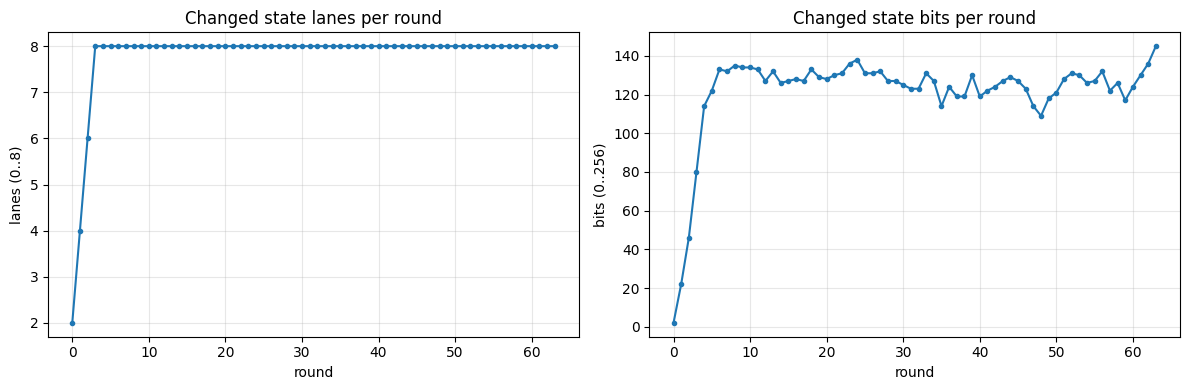

first round reaching 8/8 changed lanes = 3
first round reaching 256 changed bits = None


In [6]:
def flip_message_bit(msg: bytes, bit_index: int) -> bytes:
    out = bytearray(msg)
    byte_i, bit_i = divmod(bit_index, 8)
    out[byte_i] ^= 1 << (7 - bit_i)
    return bytes(out)

def round_state_bit_deltas(msg_a: bytes, msg_b: bytes) -> Dict[str, List[int]]:
    tr_a = sha256_trace(msg_a)
    tr_b = sha256_trace(msg_b)
    if len(tr_a.blocks) != 1 or len(tr_b.blocks) != 1:
        raise ValueError("use single-block messages for this probe")
    A = tr_a.blocks[0].state_after_rounds
    B = tr_b.blocks[0].state_after_rounds
    changed_lanes = []
    changed_bits = []
    for sA, sB in zip(A, B):
        lane_xors = [x ^ y for x, y in zip(sA, sB)]
        changed_lanes.append(sum(1 for z in lane_xors if z != 0))
        changed_bits.append(sum(hamming32(z) for z in lane_xors))
    return {"changed_lanes": changed_lanes, "changed_bits": changed_bits}

base_msg = b"A" * 32
pert_msg = flip_message_bit(base_msg, 0)
probe = round_state_bit_deltas(base_msg, pert_msg)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(range(64), probe["changed_lanes"], marker="o", ms=3)
ax[0].set_title("Changed state lanes per round")
ax[0].set_xlabel("round")
ax[0].set_ylabel("lanes (0..8)")
ax[0].grid(True, alpha=0.3)

ax[1].plot(range(64), probe["changed_bits"], marker="o", ms=3)
ax[1].set_title("Changed state bits per round")
ax[1].set_xlabel("round")
ax[1].set_ylabel("bits (0..256)")
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("first round reaching 8/8 changed lanes =", next((i for i, x in enumerate(probe["changed_lanes"]) if x == 8), None))
print("first round reaching 256 changed bits =", next((i for i, x in enumerate(probe["changed_bits"]) if x == 256), None))


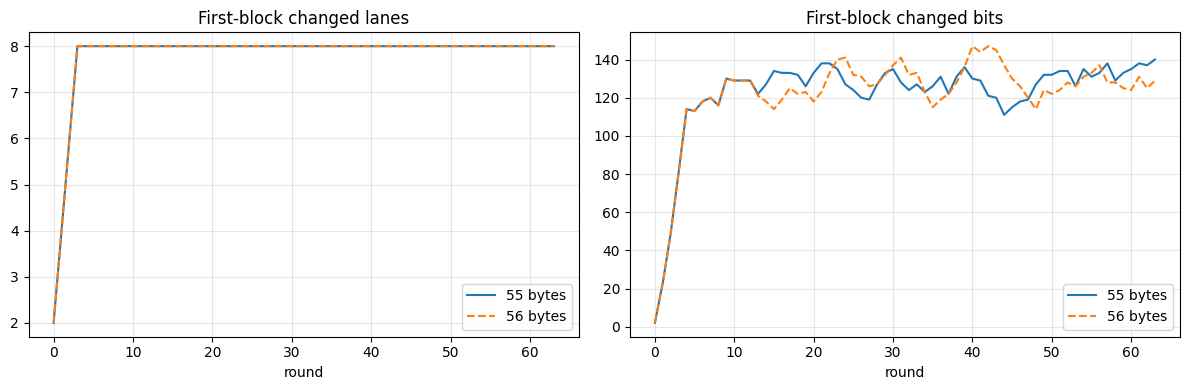

In [7]:
# Block boundary transport check:
# compare support onset for a 55-byte vs 56-byte message when one source bit is flipped.
def first_block_probe(msg: bytes, bit_index: int = 0) -> Dict[str, List[int]]:
    pert = flip_message_bit(msg, bit_index)
    tr_a = sha256_trace(msg)
    tr_b = sha256_trace(pert)
    A = tr_a.blocks[0].state_after_rounds
    B = tr_b.blocks[0].state_after_rounds
    changed_lanes = []
    changed_bits = []
    for sA, sB in zip(A, B):
        lane_xors = [x ^ y for x, y in zip(sA, sB)]
        changed_lanes.append(sum(1 for z in lane_xors if z != 0))
        changed_bits.append(sum(hamming32(z) for z in lane_xors))
    return {"changed_lanes": changed_lanes, "changed_bits": changed_bits}

p55 = first_block_probe(b"x" * 55)
p56 = first_block_probe(b"x" * 56)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(p55["changed_lanes"], label="55 bytes")
ax[0].plot(p56["changed_lanes"], label="56 bytes", linestyle="--")
ax[0].set_title("First-block changed lanes")
ax[0].set_xlabel("round")
ax[0].grid(True, alpha=0.3)
ax[0].legend()

ax[1].plot(p55["changed_bits"], label="55 bytes")
ax[1].plot(p56["changed_bits"], label="56 bytes", linestyle="--")
ax[1].set_title("First-block changed bits")
ax[1].set_xlabel("round")
ax[1].grid(True, alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()


## Section 3 — schedule branching and return ladders

This is where the wave becomes visibly **structured**.

The exact secondary law:

$$
P_{k+16,k}=
\begin{cases}
1,&k=0..8\\
3,&k=9..13\\
5,&k=14..15
\end{cases}
$$

is treated here as the first return ladder.


In [8]:
def path_multiplicity_matrix(nmax: int = 80) -> np.ndarray:
    P = np.zeros((nmax + 1, 16), dtype=np.int64)
    for k in range(16):
        P[k, k] = 1
    for i in range(16, nmax + 1):
        for k in range(16):
            v = 0
            for d in (2, 7, 15, 16):
                j = i - d
                if j >= 0:
                    v += P[j, k]
            P[i, k] = v
    return P

P = path_multiplicity_matrix(80)

rows = []
for k in range(16):
    rows.append({
        "k": k,
        "P16": int(P[k + 16, k]),
        "P32": int(P[min(k + 32, 80), k]),
        "P48": int(P[min(k + 48, 80), k]),
    })

if pd is not None:
    display(pd.DataFrame(rows))
else:
    print(rows)

print("Expected exact law:")
print("k=0..8   -> 1")
print("k=9..13  -> 3")
print("k=14..15 -> 5")


,k,P16,P32,P48
0,0,1,5,138
1,1,1,13,324
2,2,1,13,324
3,3,1,13,324
4,4,1,13,324
5,5,1,13,324
6,6,1,13,324
7,7,1,13,324
8,8,1,13,324
9,9,3,45,1204


Expected exact law:
k=0..8   -> 1
k=9..13  -> 3
k=14..15 -> 5


In [9]:
def schedule_echo_amplitude_for_word_flip(k: int, bit: int = 0) -> Dict[str, int]:
    base = [0] * 16
    pert = [0] * 16
    pert[k] = 1 << bit
    W0 = expand_schedule_from_words(base)
    W1 = expand_schedule_from_words(pert)
    hd16 = hamming32(W0[k+16] ^ W1[k+16]) if k + 16 < len(W0) else 0
    hd32 = hamming32(W0[k+32] ^ W1[k+32]) if k + 32 < len(W0) else 0
    hd48 = hamming32(W0[k+48] ^ W1[k+48]) if k + 48 < len(W0) else 0
    return {"k": k, "hd@k+16": hd16, "hd@k+32": hd32, "hd@k+48": hd48}

rows = []
for k in range(16):
    amp = schedule_echo_amplitude_for_word_flip(k, bit=0)
    rows.append({
        "k": k,
        "P16": int(P[k+16, k]),
        "P32": int(P[min(k+32, 80), k]),
        "P48": int(P[min(k+48, 80), k]),
        **amp,
    })

if pd is not None:
    df_echo = pd.DataFrame(rows)
    display(df_echo)
else:
    print(rows)

p16 = np.array([r["P16"] for r in rows], dtype=float)
h16 = np.array([r["hd@k+16"] for r in rows], dtype=float)
corr16 = np.corrcoef(p16, h16)[0, 1]

p32 = np.array([r["P32"] for r in rows], dtype=float)
h32 = np.array([r["hd@k+32"] for r in rows], dtype=float)
corr32 = np.corrcoef(p32, h32)[0, 1]

p48 = np.array([r["P48"] for r in rows], dtype=float)
h48 = np.array([r["hd@k+48"] for r in rows], dtype=float)
corr48 = np.corrcoef(p48, h48)[0, 1]

print("corr(P16, hd@k+16) =", round(float(corr16), 4))
print("corr(P32, hd@k+32) =", round(float(corr32), 4))
print("corr(P48, hd@k+48) =", round(float(corr48), 4))


,k,P16,P32,P48,hd@k+16,hd@k+32,hd@k+48
0,0,1,5,138,1,13,14
1,1,1,13,324,1,12,22
2,2,1,13,324,1,12,22
3,3,1,13,324,1,12,22
4,4,1,13,324,1,12,22
5,5,1,13,324,1,12,22
6,6,1,13,324,1,12,22
7,7,1,13,324,1,12,22
8,8,1,13,324,1,12,22
9,9,3,45,1204,3,21,19


corr(P16, hd@k+16) = 0.8987
corr(P32, hd@k+32) = 0.2594
corr(P48, hd@k+48) = -0.4443


## Section 4 — software oscilloscope

This is the main steering surface.

We stop asking only:
- “what is the value?”

and start asking:
- where does motion start?
- where does it breathe?
- where does schedule energy wake up?
- what periodicity is the fold paying for?


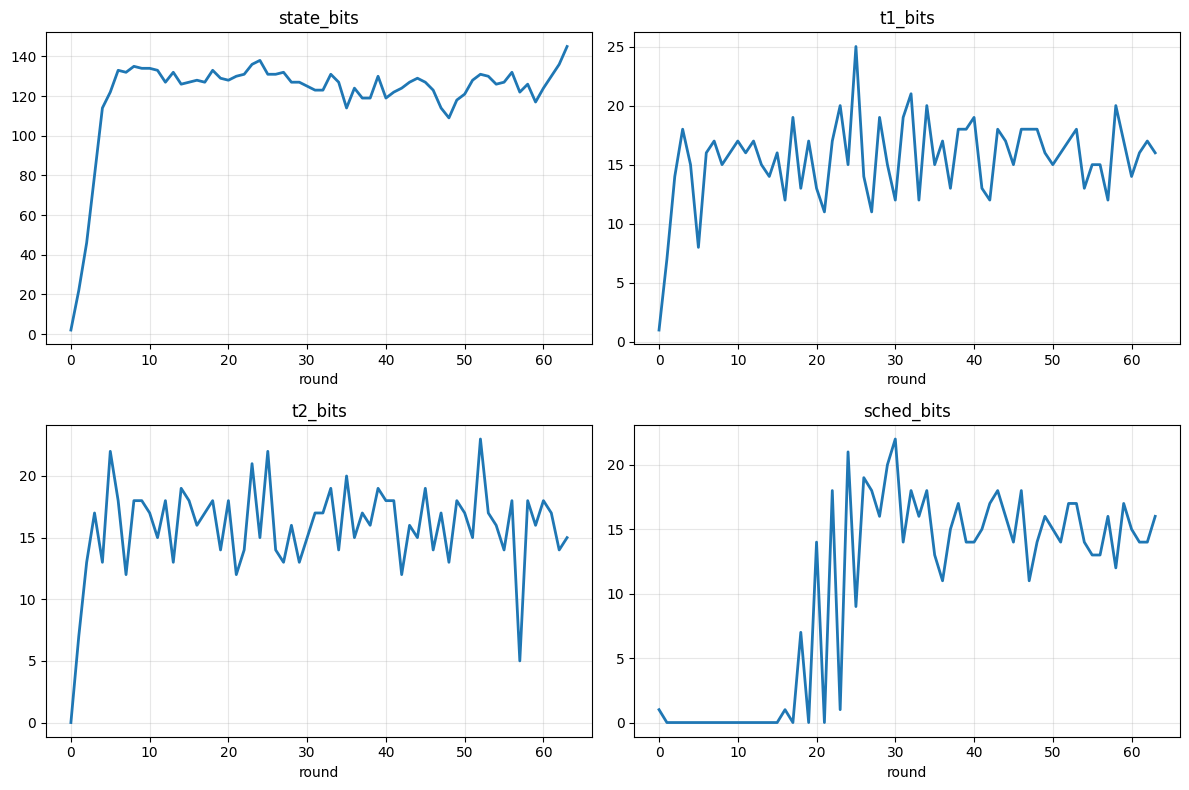

In [10]:
def divergence_spectrum(msg_a: bytes, msg_b: bytes) -> Dict[str, np.ndarray]:
    tr_a = sha256_trace(msg_a)
    tr_b = sha256_trace(msg_b)
    if len(tr_a.blocks) != 1 or len(tr_b.blocks) != 1:
        raise ValueError("use single-block messages for waveform overlay")
    blk_a = tr_a.blocks[0]
    blk_b = tr_b.blocks[0]

    state_bits = []
    t1_bits = []
    t2_bits = []
    sched_bits = []

    for t in range(64):
        state_bits.append(sum(hamming32(x ^ y) for x, y in zip(
            blk_a.state_after_rounds[t], blk_b.state_after_rounds[t]
        )))
        t1_bits.append(hamming32(blk_a.T1[t] ^ blk_b.T1[t]))
        t2_bits.append(hamming32(blk_a.T2[t] ^ blk_b.T2[t]))
        sched_bits.append(hamming32(blk_a.schedule[t] ^ blk_b.schedule[t]))

    return {
        "state_bits": np.array(state_bits, dtype=float),
        "t1_bits": np.array(t1_bits, dtype=float),
        "t2_bits": np.array(t2_bits, dtype=float),
        "sched_bits": np.array(sched_bits, dtype=float),
    }

base = b"A" * 32
pert = flip_message_bit(base, 0)
spec = divergence_spectrum(base, pert)

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
for axis, name in zip(ax.ravel(), ["state_bits", "t1_bits", "t2_bits", "sched_bits"]):
    axis.plot(spec[name], lw=2)
    axis.set_title(name)
    axis.set_xlabel("round")
    axis.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


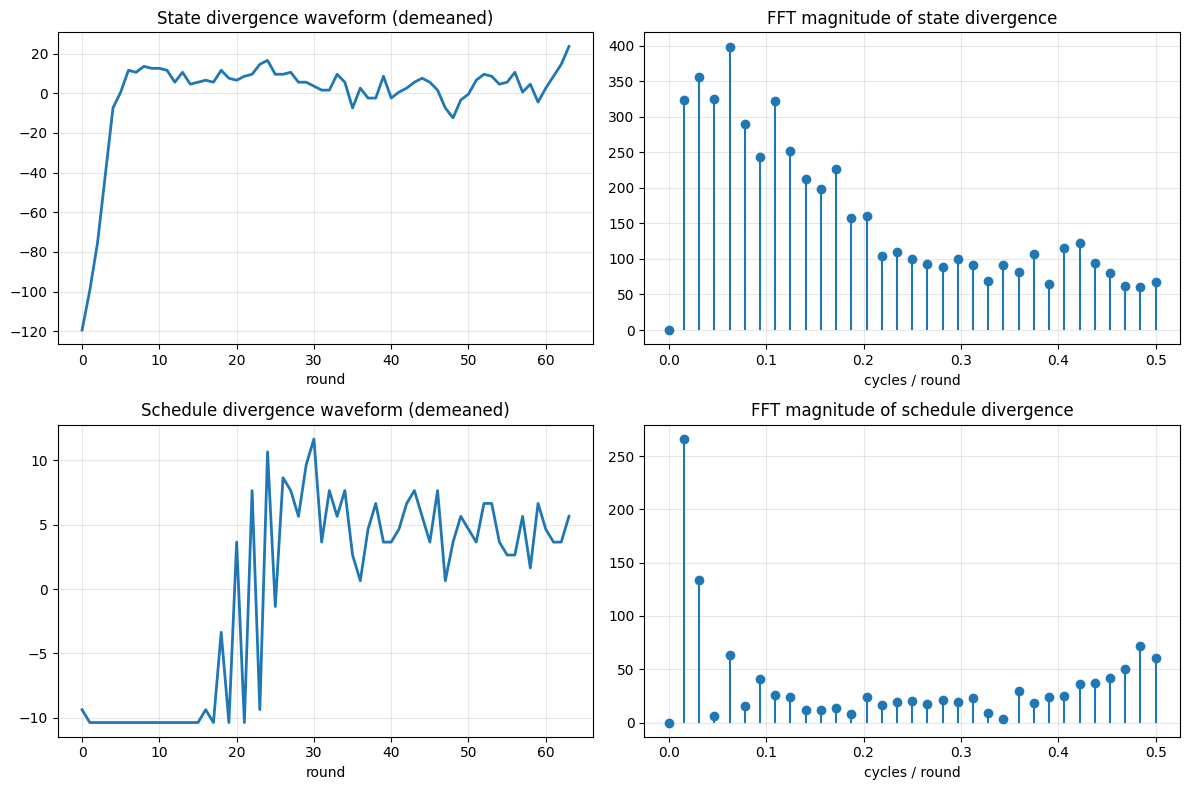

dominant state FFT bin = 4
dominant state normalized frequency = 0.0625
dominant schedule FFT bin = 1
dominant schedule normalized frequency = 0.015625
schedule implied period ≈ 64.0 rounds


In [11]:
def fft_features(x: np.ndarray) -> Dict[str, np.ndarray]:
    x = np.asarray(x, dtype=float)
    x0 = x - x.mean()
    Y = np.fft.rfft(x0)
    freqs = np.fft.rfftfreq(len(x0), d=1.0)
    amps = np.abs(Y)
    return {"freqs": freqs, "amps": amps, "signal": x0}

features_state = fft_features(spec["state_bits"])
features_sched = fft_features(spec["sched_bits"])

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

ax[0,0].plot(features_state["signal"], lw=2)
ax[0,0].set_title("State divergence waveform (demeaned)")
ax[0,0].set_xlabel("round")
ax[0,0].grid(True, alpha=0.3)

ax[0,1].stem(features_state["freqs"], features_state["amps"], basefmt=" ")
ax[0,1].set_title("FFT magnitude of state divergence")
ax[0,1].set_xlabel("cycles / round")
ax[0,1].grid(True, alpha=0.3)

ax[1,0].plot(features_sched["signal"], lw=2)
ax[1,0].set_title("Schedule divergence waveform (demeaned)")
ax[1,0].set_xlabel("round")
ax[1,0].grid(True, alpha=0.3)

ax[1,1].stem(features_sched["freqs"], features_sched["amps"], basefmt=" ")
ax[1,1].set_title("FFT magnitude of schedule divergence")
ax[1,1].set_xlabel("cycles / round")
ax[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

dom_state = int(np.argmax(features_state["amps"][1:]) + 1) if len(features_state["amps"]) > 1 else 0
dom_sched = int(np.argmax(features_sched["amps"][1:]) + 1) if len(features_sched["amps"]) > 1 else 0

print("dominant state FFT bin =", dom_state)
print("dominant state normalized frequency =", features_state["freqs"][dom_state] if dom_state else 0.0)
print("dominant schedule FFT bin =", dom_sched)
print("dominant schedule normalized frequency =", features_sched["freqs"][dom_sched] if dom_sched else 0.0)
if dom_sched:
    print("schedule implied period ≈", 1.0 / features_sched["freqs"][dom_sched], "rounds")


In [12]:
# Delay / onset view: when each channel really wakes up
def onset_index(x: np.ndarray, threshold: float) -> Optional[int]:
    for i, v in enumerate(x):
        if v >= threshold:
            return i
    return None

print("state onset >= 100 bits  :", onset_index(spec["state_bits"], 100))
print("t1 onset >= 15 bits      :", onset_index(spec["t1_bits"], 15))
print("t2 onset >= 15 bits      :", onset_index(spec["t2_bits"], 15))
print("schedule onset >= 10 bits:", onset_index(spec["sched_bits"], 10))


state onset >= 100 bits  : 4
t1 onset >= 15 bits      : 3
t2 onset >= 15 bits      : 3
schedule onset >= 10 bits: 20


## Section 5 — wave-guided pressure field

This is the steering layer.

Instead of flat search, define pressure where:
- route count is high
- spectral response is high
- return ladders are dense
- transport delay says structure is still forming

This section is exploratory, but it is the intended bridge from exact algebra to navigation.


In [13]:
def mark1_distance(x: float, H: float = math.pi / 9.0) -> float:
    return abs(x - H)

def route_weight_score(k: int) -> float:
    return float(P[k+16, k] + 0.5 * P[min(k+32, 80), k] + 0.25 * P[min(k+48, 80), k])

def spectral_energy_score(k: int) -> float:
    base_words = [0] * 16
    pert_words = [0] * 16
    pert_words[k] = 1
    W0 = np.array(expand_schedule_from_words(base_words), dtype=float)
    W1 = np.array(expand_schedule_from_words(pert_words), dtype=float)
    hd = np.array([hamming32(int(a) ^ int(b)) for a, b in zip(W0.astype(int), W1.astype(int))], dtype=float)
    F = np.abs(np.fft.rfft(hd - hd.mean()))
    return float(F[1:].max()) if len(F) > 1 else 0.0

def onset_pressure_score(k: int) -> float:
    amp = schedule_echo_amplitude_for_word_flip(k)
    return float(amp["hd@k+16"] + 0.5 * amp["hd@k+32"] + 0.25 * amp["hd@k+48"])

rows = []
for k in range(16):
    rw = route_weight_score(k)
    se = spectral_energy_score(k)
    op = onset_pressure_score(k)
    combined = rw + op + se
    rows.append({
        "k": k,
        "route_weight": rw,
        "spectral_score": se,
        "onset_pressure": op,
        "combined_score": combined,
    })

if pd is not None:
    df = pd.DataFrame(rows).sort_values("combined_score", ascending=False).reset_index(drop=True)
    display(df)
else:
    print(rows)

print("Interpretation: higher score means stronger recursive pressure and wave response.")


,k,route_weight,spectral_score,onset_pressure,combined_score
0,15,988.5,302.737599,24.50,1315.737599
1,14,988.5,298.615850,24.50,1311.615850
2,13,326.5,310.433151,18.25,655.183151
3,12,326.5,307.698804,18.25,652.448804
4,11,326.5,305.351817,18.25,650.101817
5,10,326.5,300.838941,18.25,645.588941
6,9,326.5,295.609065,18.25,640.359065
7,8,88.5,308.927035,12.50,409.927035
8,7,88.5,308.429714,12.50,409.429714
9,6,88.5,307.079057,12.50,408.079057


Interpretation: higher score means stronger recursive pressure and wave response.


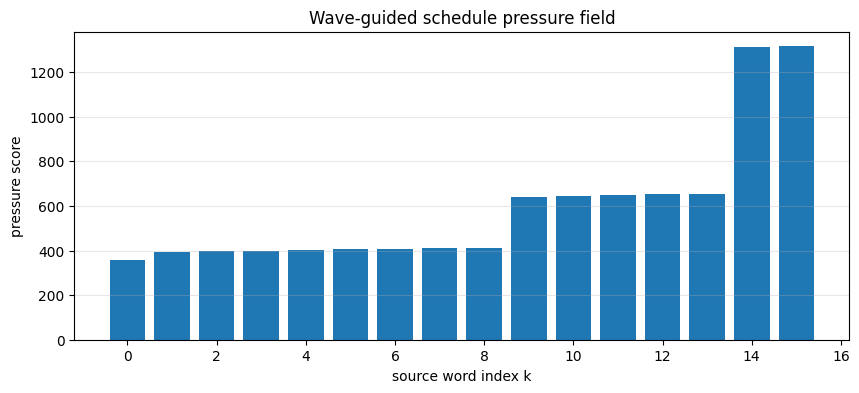

In [14]:
# Visualize the pressure field across source indices
ks = np.arange(16)
combined = np.array([r["combined_score"] for r in rows], dtype=float)

plt.figure(figsize=(10, 4))
plt.bar(ks, combined)
plt.xlabel("source word index k")
plt.ylabel("pressure score")
plt.title("Wave-guided schedule pressure field")
plt.grid(True, axis="y", alpha=0.3)
plt.show()


## Section 6 — honest baselines

This is here so the notebook does not drift away from reality.

Very short messages can be brute-forced directly.
That does **not** prove Glass Key recovery.
It is just the hard floor we compare ourselves against.


In [15]:
def brute_force_recover_1byte(digest_hex: str) -> List[bytes]:
    hits = []
    for x in range(256):
        m = bytes([x])
        if hashlib.sha256(m).hexdigest() == digest_hex:
            hits.append(m)
    return hits

def brute_force_recover_alphabet(msg_len: int, alphabet: bytes, digest_hex: str, max_hits: int = 4) -> List[bytes]:
    hits = []
    def rec(prefix: bytes):
        nonlocal hits
        if len(hits) >= max_hits:
            return
        if len(prefix) == msg_len:
            if hashlib.sha256(prefix).hexdigest() == digest_hex:
                hits.append(prefix)
            return
        for ch in alphabet:
            rec(prefix + bytes([ch]))
    rec(b"")
    return hits

target = b"A"
hits = brute_force_recover_1byte(hashlib.sha256(target).hexdigest())
print("1-byte brute-force hits =", hits)

alpha = b"ABC"
target2 = b"AB"
hits2 = brute_force_recover_alphabet(2, alpha, hashlib.sha256(target2).hexdigest())
print("2-byte alphabet-limited hits =", hits2)


1-byte brute-force hits = [b'A']
2-byte alphabet-limited hits = [b'AB']


## Section 7 — separate 112-byte branch

This is **not** the same thing as the SHA recovery path above.

It is a deterministic virtual-object protocol:
- 48-byte seed
- 64-byte anchor
- seed-driven generation
- exact replay of generator-defined objects

It stays here as a separate engineering branch.


In [16]:
GK_MAGIC = b"GK12"
GK_VERSION = 1
GK_MODEL_ID = 1
GK_SEED_SIZE = 48
GK_KEY_SIZE = 112

def make_gk_seed(length: int, user_seed: bytes, nonce: int = 0, chunk_size: int = 1 << 20) -> bytes:
    if len(user_seed) != 16:
        raise ValueError("user_seed must be 16 bytes")
    return (
        GK_MAGIC
        + struct.pack(">BBHQQQ", GK_VERSION, GK_MODEL_ID, 0, length, chunk_size, nonce)
        + user_seed
    )

def gk_iter_chunks(seed48: bytes, limit: Optional[int] = None):
    _, _, _, length, chunk_size, nonce = struct.unpack(">BBHQQQ", seed48[4:32])
    total = length if limit is None else min(length, limit)
    emitted = 0
    idx = 0
    while emitted < total:
        take = min(chunk_size, total - emitted)
        h = hashlib.sha512(seed48 + idx.to_bytes(8, "big")).digest()
        out = bytearray()
        counter = idx
        while len(out) < take:
            out.extend(hashlib.sha512(seed48 + counter.to_bytes(8, "big")).digest())
            counter += 1
        yield bytes(out[:take])
        emitted += take
        idx += 1

def gk_make_key(length: int, user_seed: bytes, nonce: int = 0, chunk_size: int = 1 << 20) -> bytes:
    seed48 = make_gk_seed(length, user_seed, nonce, chunk_size)
    sha = hashlib.sha512()
    for chunk in gk_iter_chunks(seed48):
        sha.update(chunk)
    return seed48 + sha.digest()

gk = gk_make_key(1 << 20, bytes.fromhex("00112233445566778899aabbccddeeff"), nonce=42)
print("virtual-object Glass Key size =", len(gk), "bytes")
print("seed head =", gk[:16].hex(), "...")
print("anchor head =", gk[48:64].hex(), "...")


virtual-object Glass Key size = 112 bytes
seed head = 474b3132010100000000000000100000 ...
anchor head = d7a745357a8fbc8a5987144da5f279f8 ...


## Suggested next steps

1. Replace the brute-force section with a real **single-block constrained solver**.
2. Use the **wave-guided pressure field** to prioritize unknown schedule locations near the hard seam.
3. Promote the FFT / onset / route structure into a real candidate-ranking engine.
4. Keep the 112-byte generator branch separate from hash-recovery claims.
5. Add multi-message dashboards so the pressure field can be compared across alphabets, lengths, and structured inputs.

This notebook treats the wave as the main steering instrument, not as an afterthought.
